In [26]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

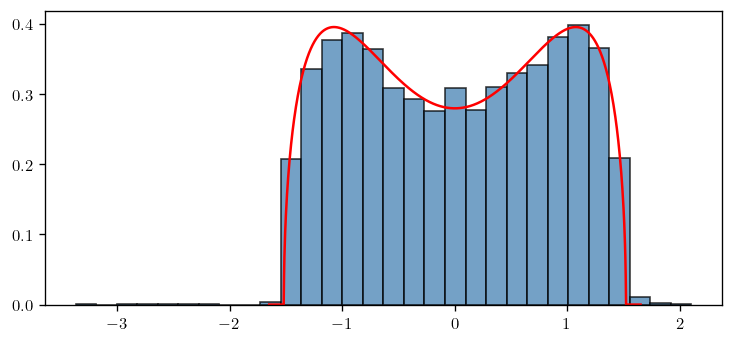

In [7]:
N = 20; M = 10; dt = 1/N**2; beta = 2; potential_name = "quartic"
init = random_matrix.init_gue_eigenvalues(M, N)
euler_pipe = simulate.make_euler_pipeline(dt = dt, potential_type = potential_name, beta = beta)
traj = simulate.simulate_dbm(init, int(3.0/dt), euler_pipe)
particles = simulate.collect_snapshots(traj, int(3.0/dt))

density_range, limiting_density = densities.get_density(potential_name)

fig, ax = plt.subplots(figsize = (6, 2.75))
ax.hist(particles, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
ax.grid(False)

plt.show()

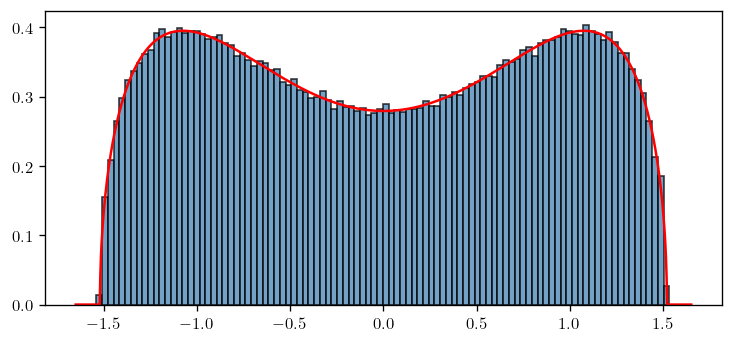

In [12]:
def test_method(method, N = 40, beta = 2.0, T = 5.0, M = 250, potential_name = "quartic", num_bins = 30):
    """ 
    Test method by plotting histograms when init with GUE and given quartic potential.
    """

    if (method == "implicit" or method == "imla"):
        dt = 0.1
    else:
        dt = 1/(N**2)

    total_steps = int(T/dt)
    init = random_matrix.init_gue_eigenvalues(M, N)
    pipe = simulate.get_pipeline(method, N = N, dt = dt, potential_type = potential_name, beta = beta)

    traj = simulate.simulate_dbm(init, total_steps, pipe)
    particles = simulate.collect_snapshots(traj, total_steps)

    # Quick plotter.
    density_range, limiting_density = densities.get_density(potential_name)

    fig, ax = plt.subplots(figsize = (6, 2.75))
    ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
    ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
    ax.grid(False)

    plt.show()

test_method("implicit", N = 100, num_bins = 100)

---


MALA test.

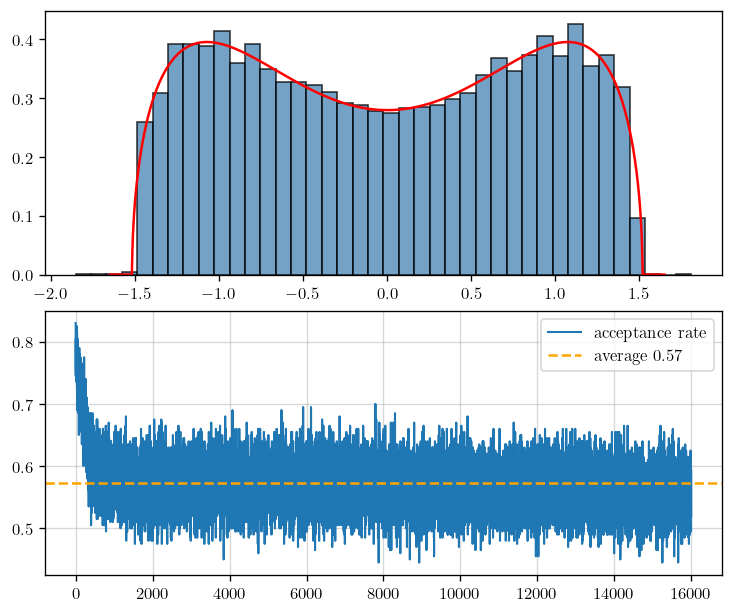

In [ ]:
N = 40; beta = 2.0; T = 10.0; M = 200;
dt = 1/(N**2); total_steps = int(T/dt);
potential_name = "quartic"

init = random_matrix.init_gue_eigenvalues(M, N)
mala_pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
particles, accepts = simulate.metropolis_experiment(traj, total_steps)

fig, axes = plt.subplots(2, 1, figsize = (6, 5.0))
ax1, ax2 = axes

plotters.plot_hist(ax1, particles, potential_name = potential_name, num_bins = 40)
plotters.plot_accepts(ax2, accepts)

plt.show()